# Notebook 00: Data Generation & Exploration

**Research question:** What did the active campaign decisions contribute above what baseline spend would have earned from the demand wave alone

**Dataset:** Trend shift — flat through Jun 2025, then +0.4%/day from Jul 1.

**Why this dataset:** The trend shift exposes the failure mode of every observational method.
A flat dataset is the easy case — all methods eventually work. Any company with double-digit
YoY growth faces a version of this problem.

**Ground truth:** Because the data is synthetic, the true paid increment can be computed directly as PS observed lift (126.7%) − average organic donor lift (55.0%) = **71.6% = $1,340/day**.

One caveat worth stating: this definition is structurally aligned with the donor-based counterfactual framework. It defines the true increment as the gap between PS and its organic demand channels — which is exactly what SC estimates. A fully independent ground truth would require a randomized holdout. In its absence, this is the most defensible definition available, but the circularity should be acknowledged rather than ignored.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from generate_data import (
    generate_dataset, BF2025_START, BF2025_END,
    CHANNELS, DONOR_CHANNELS, TREATED_CHANNEL
)
from utils import (
    set_style, save_figure, add_intervention_band, add_bf2024_band,
    add_trend_shift_line, format_date_axis, usd_formatter,
    DATA_DIR, PALETTE, INTERVENTION_START, SC_PRE_START
)

set_style()
df, gt = generate_dataset(seed=42, data_dir=DATA_DIR)

TRUE_DAILY = gt['true_increment_usd']
print(f'Ground truth: ${TRUE_DAILY:,.0f}/day  ({gt["true_increment_pct"]}%)')
print(f'PS observed BF lift: {gt["ps_lift_observed_pct"]}%  (planted 150%)')
print(f'Organic donor lift:  {gt["organic_lift_obs_pct"]}%')
print(f'Nov baseline: ${gt["ps_imm_pre_mean_usd"]:,.0f}/day  |  BF mean: ${gt["ps_bf_mean_usd"]:,.0f}/day')

Saved: dataset.csv  (4,386 rows)
Ground truth: $1,340/day  (71.6%)
PS observed BF lift: 126.7%  (planted 150%)
Organic donor lift:  55.0%
Nov baseline: $1,871/day  |  BF mean: $4,241/day


## 1. All channels — full series

Saved: 00a_all_channels.png


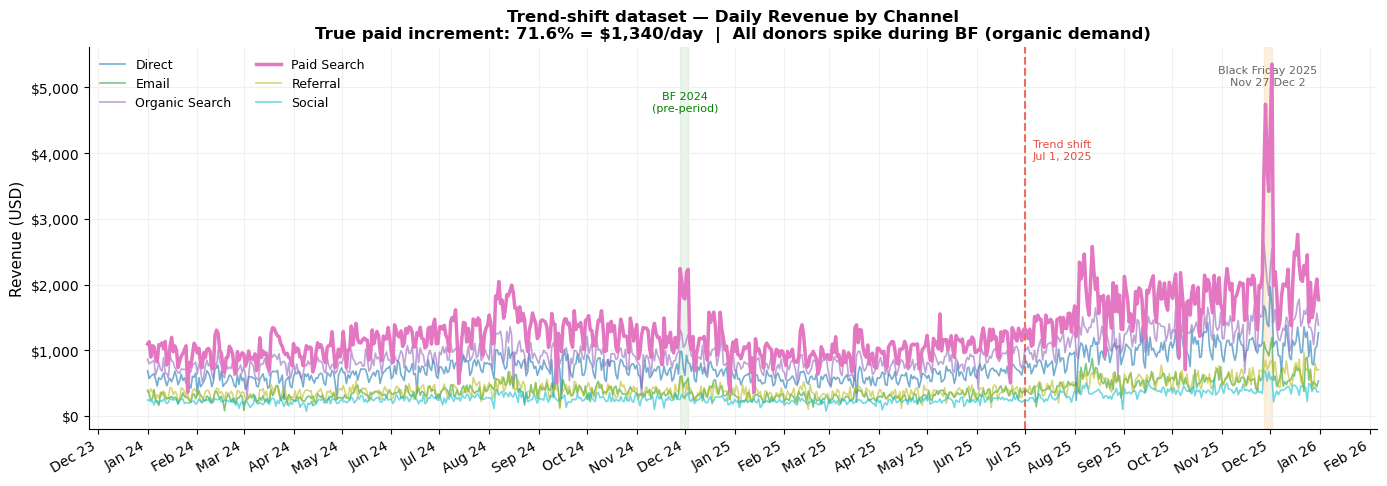

In [2]:
channels = sorted(df.channel.unique())
colors   = plt.cm.tab10(np.linspace(0, 1, len(channels)))
ch_color = dict(zip(channels, colors))

fig, ax = plt.subplots(figsize=(14, 5))
for ch in channels:
    s  = df[df.channel==ch].set_index('date')['revenue_usd']
    lw = 2.5 if ch == TREATED_CHANNEL else 1.2
    ax.plot(s.index, s, lw=lw, alpha=1.0 if ch==TREATED_CHANNEL else 0.6,
            color=ch_color[ch], label=ch, zorder=5 if ch==TREATED_CHANNEL else 3)
add_intervention_band(ax)
add_bf2024_band(ax)
add_trend_shift_line(ax)
format_date_axis(ax)
ax.set_title(
    f'Trend-shift dataset — Daily Revenue by Channel\n'
    f'True paid increment: {gt["true_increment_pct"]}% = '
    f'${TRUE_DAILY:,.0f}/day  |  All donors spike during BF (organic demand)'
)
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(usd_formatter())
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
save_figure(fig, '00a_all_channels')
plt.show()

## 2. Observed BF lifts — planted vs actual

In [3]:
bf_mask  = (df.date >= BF2025_START) & (df.date <= BF2025_END)
pre_mask = (df.date >= '2025-11-01') & (df.date < BF2025_START)

print(f'  {"Channel":<20} {"Nov baseline":>12} {"BF mean":>10} {"Lift":>8} {"Planted":>9}  Role')
print('  ' + '-'*68)
for ch in [TREATED_CHANNEL] + DONOR_CHANNELS + ['Email']:
    pre  = df.loc[(df.channel==ch) & pre_mask, 'revenue_usd'].mean()
    bf   = df.loc[(df.channel==ch) & bf_mask,  'revenue_usd'].mean()
    pla  = CHANNELS[ch]['bf_lift'] * 100
    role = 'TREATED' if ch==TREATED_CHANNEL else ('donor' if CHANNELS[ch]['donor'] else 'excluded')
    print(f'  {ch:<20} ${pre:>10,.0f} ${bf:>9,.0f} {(bf/pre-1)*100:>7.1f}% {pla:>8.0f}%  {role}')
print(f'\nTrue increment = {gt["ps_lift_observed_pct"]}% (PS) - {gt["organic_lift_obs_pct"]}% (organic avg) '
      f'= {gt["true_increment_pct"]}% = ${TRUE_DAILY:,.0f}/day')

  Channel              Nov baseline    BF mean     Lift   Planted  Role
  --------------------------------------------------------------------
  Paid Search          $     1,871 $    4,241   126.7%      150%  TREATED
  Organic Search       $     1,318 $    2,278    72.9%       65%  donor
  Direct               $     1,048 $    1,616    54.2%       55%  donor
  Referral             $       582 $      783    34.6%       45%  donor
  Social               $       391 $      620    58.5%       55%  donor
  Email                $       537 $    1,048    95.0%       85%  excluded

True increment = 126.7% (PS) - 55.0% (organic avg) = 71.6% = $1,340/day


## Summary

| Metric | Value |
|---|---|
| PS BF lift (observed) | 126.7% vs Nov 1-26 baseline |
| Organic donor lift (avg) | 55.0% |
| **True paid increment** | **71.6% = $1,340/day** |
| Nov 1-26 baseline | $1,871/day (+54% from trend shift) |
| BF window mean | $4,241/day |

All donors spike during BF — this is expected organic consumer behavior, not contamination.
The SC counterfactual in notebook 03 uses that organic spike as the baseline.
The gap above it is the paid increment.

Run notebooks in order: `01` → `02` → `03` → `04`